# Incremental wNum Learning Pipeline

This notebook implements **curriculum-style incremental training** that exploits the
relationship between `wNum` (depth in the difference chain) and prediction certainty.

## Key Idea

Higher `wNum` nodes have longer difference chains, making root-count predictions more
deterministic. Lower `wNum` nodes are inherently noisier. By training from high to low
`wNum` thresholds, the model first learns on the most certain examples before
progressively incorporating harder ones.

## Pipeline

1. **Discover** the distinct `wNum` values in the graph
2. **For each level** (`min_wnum` from `wNum_max` down to `0`):
   - Load graph with `cb.wNum >= min_wnum`
   - Train all configured models
   - Collect metrics
3. **Aggregate** and **visualise** metrics vs `min_wnum`


In [1]:
# Force reload of graph_label_prediction modules to pick up code changes
import importlib
import sys

modules_to_reload = [m for m in sys.modules.keys() if m.startswith('graph_label_prediction')]
for module in modules_to_reload:
    del sys.modules[module]

print(f"Cleared {len(modules_to_reload)} cached modules")

Cleared 0 cached modules


## 1. Imports

In [2]:
import os
import json
import sys
from pathlib import Path
from datetime import datetime

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Add parent directory to path for pipeline modules
ml_path = Path('.').absolute().parent.parent
if str(ml_path) not in sys.path:
    sys.path.insert(0, str(ml_path))

neo4j_path = ml_path / 'neo4j'
if str(neo4j_path) not in sys.path:
    sys.path.insert(0, str(neo4j_path))

from neo4jClient import Neo4jClient

from graph_label_prediction.python_model.core.data_loader import GraphDataLoader
from graph_label_prediction.python_model.core.config import (
    WNUM_DISCOVERY_QUERY,
    SPECTRAL_PE_DIM,
    NUM_BASE_FEATURES,
    NUM_COEFFICIENT_FEATURES,
    NUM_STATISTICAL_FEATURES,
    NUM_SET_UNION_FEATURES,
)
from graph_label_prediction.python_model.core.experiment import (
    ExperimentConfig, ExperimentRunner, ExperimentReport,
)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print("Imports successful")

PyTorch version: 2.9.1+cpu
CUDA available: False
Imports successful


## 2. Load Environment and Connect to Neo4j

In [3]:
# Load environment variables from .env file
env_paths = [Path('.env'), Path('../.env'), Path('../../.env')]

for env_path in env_paths:
    if env_path.exists():
        load_dotenv(env_path, override=True)
        print(f"Loaded .env from: {env_path.absolute()}")
        break

NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE", "neo4j")

print(f"\nConnection Configuration:")
print(f"  URI: {NEO4J_URI}")
print(f"  User: {NEO4J_USER}")
print(f"  Password: {'*' * len(NEO4J_PASSWORD) if NEO4J_PASSWORD else 'NOT SET'}")
print(f"  Database: {NEO4J_DATABASE}")

Loaded .env from: c:\Users\tomas\JavaProjects\Aibeceles\ml\graph_label_prediction\workbooks\..\..\.env

Connection Configuration:
  URI: bolt://localhost:7687
  User: neo4j
  Password: ***********
  Database: d5seed1


In [4]:
try:
    client = Neo4jClient(
        uri=NEO4J_URI,
        user=NEO4J_USER,
        password=NEO4J_PASSWORD
    )
    print("Neo4j client initialized successfully")

    test_query = "MATCH (n:Dnode) RETURN count(n) AS total_nodes"
    result = client.run_query(test_query, NEO4J_DATABASE)
    print(f"Database contains {result['total_nodes'].iloc[0]:,} Dnode nodes")

except ConnectionError as e:
    print(f"Connection failed: {e}")
    raise

Neo4j client initialized successfully
Database contains 3,024,769 Dnode nodes


## 3. Discover wNum Range

Query the database for all distinct `wNum` values (subject to the same pArrayList
constraint used by the filtered queries) so we know the iteration bounds.

In [5]:
# Discover distinct wNum values and their node counts
wnum_df = client.run_query(WNUM_DISCOVERY_QUERY, NEO4J_DATABASE)

print("wNum distribution in graph (pArrayList in [-10, 10)):")
print(wnum_df.to_string(index=False))

wnum_values = sorted(wnum_df['wNum'].tolist())
wnum_max = max(wnum_values)
wnum_min = min(wnum_values)

print(f"\nwNum range: [{wnum_min}, {wnum_max}]")
print(f"Distinct wNum levels: {len(wnum_values)}")
print(f"Incremental iterations: {wnum_max - wnum_min + 1} (from {wnum_max} down to {wnum_min})")

wNum distribution in graph (pArrayList in [-10, 10)):
 wNum  nodeCount
    5     232431
    4     232431
    3     232431
    2     232431
    1     232431
    0     232431

wNum range: [0, 5]
Distinct wNum levels: 6
Incremental iterations: 6 (from 5 down to 0)


## 4. Discover Max Classes and Define Experiment Configurations

To enable curriculum weight transfer across wNum levels (where `num_classes` may
increase at lower thresholds), we first discover the global `max_num_classes` from
the full graph (`wNum >= 0`). All models are pre-allocated with this output head
size so that `state_dict` transfers work cleanly across levels.

Same model list as `run_pipeline_refactor_1.ipynb` for comparability.

In [6]:
# Discover the global max num_classes from the full graph (wNum >= 0)
# so all models can be pre-allocated with a fixed output head size.
print("Loading full graph (wNum >= 0) to discover max num_classes...")
full_loader = GraphDataLoader(client, NEO4J_DATABASE, min_wnum=0)
full_data = full_loader.load()
max_num_classes = full_data.num_classes
del full_data, full_loader  # free memory
print(f"Global max_num_classes = {max_num_classes}\n")

# LR decay factor per curriculum level (applied after the first level)
LR_DECAY = 0.5

configs = [
    ExperimentConfig(name="GraphSAGE-CE-relu",    model_name="graphsage",        loss_type="ce",    model_kwargs={"num_classes": max_num_classes}),
    ExperimentConfig(name="GraphSAGE-Focal-relu",  model_name="graphsage",        loss_type="focal", model_kwargs={"num_classes": max_num_classes}),
    ExperimentConfig(name="MLP-CE-relu",           model_name="mlp",              loss_type="ce",    model_kwargs={"num_classes": max_num_classes}),
    ExperimentConfig(name="GAT-CE-elu",            model_name="depth_aware_gat",  loss_type="ce",    activation="elu", model_kwargs={"num_classes": max_num_classes}),
    ExperimentConfig(name="GAT-Focal-elu",         model_name="depth_aware_gat",  loss_type="focal", activation="elu", model_kwargs={"num_classes": max_num_classes}),
    ExperimentConfig(name="CORAL-CE-relu",         model_name="coral",            loss_type="ce",    model_kwargs={"num_classes": max_num_classes}),
]

print(f"Configured {len(configs)} experiments per wNum level:")
for cfg in configs:
    print(f"  {cfg.name}  (model={cfg.model_name}, loss={cfg.loss_type}, act={cfg.activation}, num_classes={max_num_classes})")
print(f"\nLR decay per level: {LR_DECAY}")

Loading full graph (wNum >= 0) to discover max num_classes...
Using incremental queries (wNum >= 0)...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }', position=<SummaryInputPosition line=4, column=1, offset=29>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 29, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (dd:Dnode)   \nWITH dd\nCALL {\n     WITH dd\n     MATCH (dd)-[:CreatedBye]->(cb)\n     WHERE ( all(x IN cb.pArrayList WHERE x >= -10 AND x < 10 ) AND (cb.wNum >= 0))\n     WITH dd AS d, cb.wNum AS wNum LIMIT 1

Label mapping: 6 classes present [0, 1, 2, 3, 4, 5] -> [0..5]


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }', position=<SummaryInputPosition line=4, column=1, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 24, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)\nWITH d\nCALL {\n     WITH d\n     MATCH (d)-[:CreatedBye]->(cb)\n     WHERE ( all(x IN cb.pArrayList WHERE x >= -10 AND x < 10 ) AND (cb.wNum >= 0))\n     WITH DISTINCT d AS unique_D\n     RETURN uniqu

Graph has 144,396 nodes (>100,000)
Skipping spectral PE computation (requires too much memory)
Using only base features as input (dim=3)
Global max_num_classes = 6

Configured 6 experiments per wNum level:
  GraphSAGE-CE-relu  (model=graphsage, loss=ce, act=relu, num_classes=6)
  GraphSAGE-Focal-relu  (model=graphsage, loss=focal, act=relu, num_classes=6)
  MLP-CE-relu  (model=mlp, loss=ce, act=relu, num_classes=6)
  GAT-CE-elu  (model=depth_aware_gat, loss=ce, act=elu, num_classes=6)
  GAT-Focal-elu  (model=depth_aware_gat, loss=focal, act=elu, num_classes=6)
  CORAL-CE-relu  (model=coral, loss=ce, act=relu, num_classes=6)

LR decay per level: 0.5


## 5. Curriculum Training Loop (Weight Transfer + Frontier Supervision)

For each `min_wnum` from `wNum_max` down to `wNum_min`:
1. Load the graph with `cb.wNum >= min_wnum`
2. Build a **frontier mask** (`wNum == min_wnum`) so the loss is computed only on newly-introduced nodes; higher-wNum nodes still participate in GNN message passing as context
3. Train all experiment configs -- **restoring weights from the previous level**
4. Save model checkpoints for the next level
5. Decay learning rate to prevent catastrophic forgetting

The first level trains from scratch on all nodes. Subsequent levels fine-tune
from the previous checkpoint with frontier-only supervision.

In [7]:
import copy

incremental_results = []  # List[Dict] with keys: min_wnum, num_nodes, num_edges, num_classes, report
checkpoints = {}          # config.name -> state_dict (carried between levels)
level_idx = 0             # tracks how many levels have actually trained

for min_wnum in range(wnum_max, wnum_min - 1, -1):
    print(f"\n{'#' * 80}")
    print(f"# INCREMENTAL LEVEL: min_wnum = {min_wnum}  (level {level_idx})")
    print(f"{'#' * 80}")

    # 1. Load graph at this wNum threshold
    loader = GraphDataLoader(client, NEO4J_DATABASE, min_wnum=min_wnum)
    try:
        data = loader.load()
    except ValueError as e:
        print(f"  Skipping min_wnum={min_wnum}: {e}")
        continue

    stats = loader.get_graph_stats(data)
    print(f"  Nodes: {stats['num_nodes']:,}  |  Edges: {stats['num_edges']:,}  |  Classes: {data.num_classes}")
    print(f"  Class distribution: {stats['class_distribution']}")

    # Skip if insufficient nodes/edges for training
    min_class_count = min(stats['class_distribution'].values()) if stats['class_distribution'] else 0
    if stats['num_edges'] == 0:
        print(f"  Skipping min_wnum={min_wnum}: no edges (isolated node(s))")
        continue
    if data.num_nodes < 10 or min_class_count < 2:
        print(f"  Skipping min_wnum={min_wnum}: too few nodes ({data.num_nodes}) or min class count ({min_class_count}) < 2")
        continue

    # 2. Build level-specific configs with decayed LR
    current_lr_scale = LR_DECAY ** level_idx
    level_configs = [
        ExperimentConfig(
            name=cfg.name,
            model_name=cfg.model_name,
            loss_type=cfg.loss_type,
            activation=cfg.activation,
            weight_decay=cfg.weight_decay,
            learning_rate=cfg.learning_rate * current_lr_scale,
            hidden_dim=cfg.hidden_dim,
            dropout=cfg.dropout,
            max_epochs=cfg.max_epochs,
            patience=cfg.patience,
            feature_set=cfg.feature_set,
            edge_feature_set=cfg.edge_feature_set,
            model_kwargs=cfg.model_kwargs.copy(),
        )
        for cfg in configs
    ]
    print(f"  LR scale: {current_lr_scale:.4f} (base * {LR_DECAY}^{level_idx})")
    if checkpoints:
        print(f"  Restoring checkpoints from previous level ({len(checkpoints)} models)")

    # 3. Build frontier mask: only nodes at the current wNum level
    # First level: all nodes are frontier (no prior context).
    # Subsequent levels: supervise only newly-added nodes;
    # higher-wNum nodes still participate in message passing as context.
    if level_idx == 0:
        frontier_mask = None  # all nodes are frontier at first level
    else:
        frontier_mask = (data.wNum == min_wnum)
        n_frontier = frontier_mask.sum().item()
        n_total = data.num_nodes
        print(f"  Frontier nodes (wNum={min_wnum}): {n_frontier} / {n_total} ({100*n_frontier/n_total:.1f}%)")

    # 4. Train all models (with checkpoint restoration + frontier supervision)
    runner = ExperimentRunner(data, trainer_kwargs={'use_class_weights': True})
    report = runner.run_all(level_configs, verbose=False, checkpoints=checkpoints, frontier_mask=frontier_mask)

    # 5. Save checkpoints for the next level
    for cfg, model in zip(report.configs, report.models):
        checkpoints[cfg.name] = copy.deepcopy(model.state_dict())

    # Print quick summary for this level
    best = report.best()
    if best:
        print(f"  Best model: {best['name']}  Macro F1={best.get('test_macro_f1', 0):.4f}")

    # 6. Store results
    incremental_results.append({
        'min_wnum': min_wnum,
        'num_nodes': stats['num_nodes'],
        'num_edges': stats['num_edges'],
        'num_classes': data.num_classes,
        'class_distribution': stats['class_distribution'],
        'report': report,
    })
    level_idx += 1

print(f"\n{'=' * 80}")
print(f"Completed {len(incremental_results)} incremental levels (curriculum with weight transfer)")
print(f"{'=' * 80}")


################################################################################
# INCREMENTAL LEVEL: min_wnum = 5  (level 0)
################################################################################
Using incremental queries (wNum >= 5)...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }', position=<SummaryInputPosition line=4, column=1, offset=29>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 29, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (dd:Dnode)   \nWITH dd\nCALL {\n     WITH dd\n     MATCH (dd)-[:CreatedBye]->(cb)\n     WHERE ( all(x IN cb.pArrayList WHERE x >= -10 AND x < 10 ) AND (cb.wNum >= 5))\n     WITH dd AS d, cb.wNum AS wNum LIMIT 1

Label mapping: 1 classes present [0] -> [0..0]


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }', position=<SummaryInputPosition line=4, column=1, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 24, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)\nWITH d\nCALL {\n     WITH d\n     MATCH (d)-[:CreatedBye]->(cb)\n     WHERE ( all(x IN cb.pArrayList WHERE x >= -10 AND x < 10 ) AND (cb.wNum >= 5))\n     WITH DISTINCT d AS unique_D\n     RETURN uniqu

Computing spectral positional encodings for 1 nodes...
  Feature dim: 25 (17 base+coeff+stats+set_union + 8 spectral PE)
  Nodes: 1  |  Edges: 0  |  Classes: 1
  Class distribution: {0: 1}
  Skipping min_wnum=5: no edges (isolated node(s))

################################################################################
# INCREMENTAL LEVEL: min_wnum = 4  (level 0)
################################################################################
Using incremental queries (wNum >= 4)...


...

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }', position=<SummaryInputPosition line=4, column=1, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 24, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)\nWITH d\nCALL {\n     WITH d\n     MATCH (d)-[:CreatedBye]->(cb)\n     WHERE ( all(x IN cb.pArrayList WHERE x >= -10 AND x < 10 ) AND (cb.wNum >= 0))\n     WITH DISTINCT d AS unique_D\n     RETURN uniqu

Graph has 144,396 nodes (>100,000)
Skipping spectral PE computation (requires too much memory)
Using only base features as input (dim=3)
  Nodes: 144,396  |  Edges: 144,395  |  Classes: 6
  Class distribution: {0: 3, 1: 122317, 2: 18484, 3: 2801, 4: 368, 5: 423}
  LR scale: 0.1250 (base * 0.5^3)
  Restoring checkpoints from previous level (6 models)
  Frontier nodes (wNum=0): 128072 / 144396 (88.7%)
Stratified split (guaranteed class coverage):
  Train: 93858 | Val: 21659 | Test: 28879
  Train classes: [0, 1, 2, 3, 4, 5]
  Val classes: [0, 1, 2, 3, 4, 5]
  Test classes: [0, 1, 2, 3, 4, 5]
Class weights (sqrt inverse frequency, normalized):
  0 roots: 5.163
  1 root: 0.018
  2 roots: 0.047
  3 roots: 0.121
  4 roots: 0.339
  5 roots: 0.312


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  

  Best model: GraphSAGE-CE-relu  Macro F1=0.2401

Completed 4 incremental levels (curriculum with weight transfer)


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 6. Aggregate Metrics

Build a single DataFrame with one row per (model, wNum-level) combination.

In [8]:
rows = []
for entry in incremental_results:
    min_wnum = entry['min_wnum']
    num_nodes = entry['num_nodes']
    num_edges = entry['num_edges']
    num_classes = entry['num_classes']
    report = entry['report']

    for cfg, metrics in zip(report.configs, report.results):
        rows.append({
            'min_wnum': min_wnum,
            'num_nodes': num_nodes,
            'num_edges': num_edges,
            'num_classes': num_classes,
            'model_name': cfg.name,
            'model': cfg.model_name,
            'loss': cfg.loss_type,
            'activation': cfg.activation,
            'test_macro_f1': metrics.get('test_macro_f1', float('nan')),
            'test_balanced_acc': metrics.get('test_balanced_acc', float('nan')),
            'test_mae': metrics.get('test_mae', float('nan')),
            'val_macro_f1': metrics.get('val_macro_f1', float('nan')),
            'test_f1_weighted': metrics.get('test_f1', float('nan')),
            'epochs_trained': metrics.get('epochs_trained', 0),
        })

agg_df = pd.DataFrame(rows)

# Compute delta metrics vs the previous (higher) wNum level
agg_df = agg_df.sort_values(['model_name', 'min_wnum'], ascending=[True, False]).reset_index(drop=True)
agg_df['delta_macro_f1'] = agg_df.groupby('model_name')['test_macro_f1'].diff()
agg_df['delta_balanced_acc'] = agg_df.groupby('model_name')['test_balanced_acc'].diff()
agg_df['delta_mae'] = agg_df.groupby('model_name')['test_mae'].diff()

print(f"Aggregated {len(agg_df)} rows ({len(agg_df['model_name'].unique())} models x {len(agg_df['min_wnum'].unique())} wNum levels)")
print()

# Display the full table sorted by min_wnum descending then model
display_df = agg_df.sort_values(['min_wnum', 'model_name'], ascending=[False, True])
display_cols = ['min_wnum', 'model_name', 'num_nodes', 'num_classes',
                'test_macro_f1', 'test_balanced_acc', 'test_mae',
                'delta_macro_f1', 'epochs_trained']
display_df[[c for c in display_cols if c in display_df.columns]]

Aggregated 24 rows (6 models x 4 wNum levels)



,min_wnum,model_name,num_nodes,num_classes,test_macro_f1,test_balanced_acc,test_mae,delta_macro_f1,epochs_trained
0,3,CORAL-CE-relu,206,3,0.297297,0.333333,0.219512,NaN,100
4,3,GAT-CE-elu,206,3,0.454844,0.518038,0.365854,NaN,100
8,3,GAT-Focal-elu,206,3,0.443192,0.428571,0.146341,NaN,100
12,3,GraphSAGE-CE-relu,206,3,0.756272,0.959596,0.195122,NaN,100
16,3,GraphSAGE-Focal-relu,206,3,0.883761,0.989899,0.048780,NaN,100
20,3,MLP-CE-relu,206,3,0.727499,0.847042,0.121951,NaN,100
1,2,CORAL-CE-relu,1853,4,0.298423,0.490741,0.371951,0.001126,100
5,2,GAT-CE-elu,1853,4,0.531157,0.550766,0.676829,0.076313,100
9,2,GAT-Focal-elu,1853,4,0.550266,0.573563,0.646341,0.107074,100
13,2,GraphSAGE-CE-relu,1853,4,0.451505,0.500000,0.353659,-0.304767,100


## 7. Visualisation: Metrics vs min_wnum

One line per model. X-axis is `min_wnum` (high on left = more selective, low on right = more inclusive).

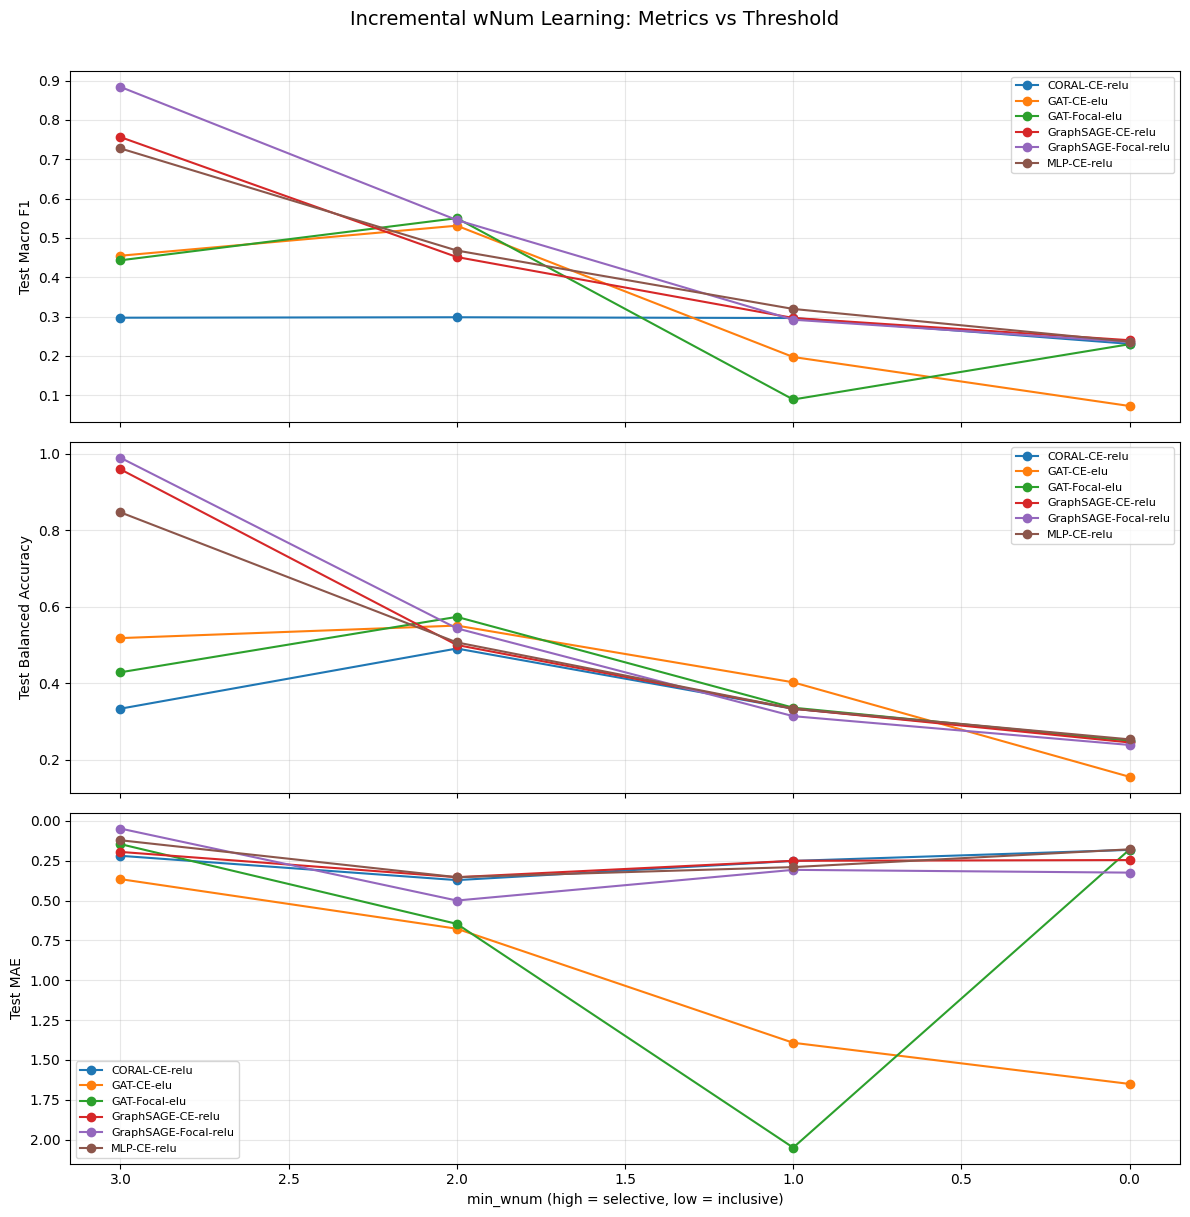

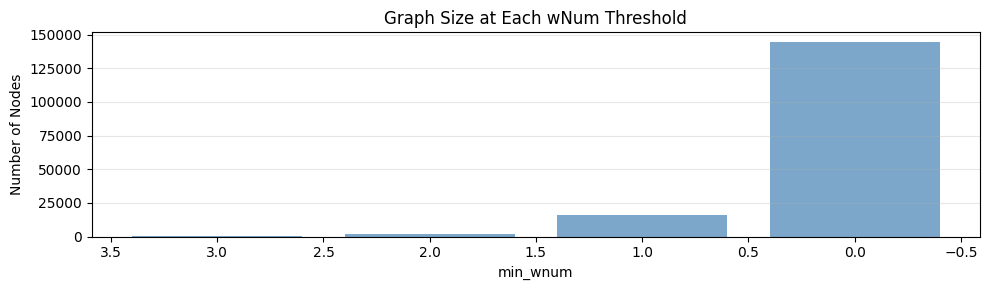

In [9]:
model_names = sorted(agg_df['model_name'].unique())
metrics_to_plot = [
    ('test_macro_f1',     'Test Macro F1'),
    ('test_balanced_acc', 'Test Balanced Accuracy'),
    ('test_mae',          'Test MAE'),
]

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 4 * len(metrics_to_plot)), sharex=True)
if len(metrics_to_plot) == 1:
    axes = [axes]

for ax, (metric_col, metric_label) in zip(axes, metrics_to_plot):
    for model_name in model_names:
        model_df = agg_df[agg_df['model_name'] == model_name].sort_values('min_wnum')
        ax.plot(model_df['min_wnum'], model_df[metric_col], marker='o', label=model_name)

    ax.set_ylabel(metric_label)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    if metric_col == 'test_mae':
        ax.invert_yaxis()  # Lower MAE is better

axes[-1].set_xlabel('min_wnum (high = selective, low = inclusive)')
axes[-1].invert_xaxis()  # High wNum on the left
fig.suptitle('Incremental wNum Learning: Metrics vs Threshold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Also plot graph size vs min_wnum
size_df = agg_df.drop_duplicates('min_wnum').sort_values('min_wnum')
fig2, ax2 = plt.subplots(figsize=(10, 3))
ax2.bar(size_df['min_wnum'], size_df['num_nodes'], color='steelblue', alpha=0.7)
ax2.set_xlabel('min_wnum')
ax2.set_ylabel('Number of Nodes')
ax2.set_title('Graph Size at Each wNum Threshold')
ax2.invert_xaxis()
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8. Summary Table

Best model at each wNum level, and overall best (model, wNum) combination.

In [10]:
# Best model at each wNum level
print("BEST MODEL PER wNum LEVEL")
print("=" * 90)
header = f"{'min_wnum':>8}  {'Nodes':>7}  {'Classes':>7}  {'Best Model':<30}  {'Macro F1':>8}  {'BalAcc':>8}  {'MAE':>8}"
print(header)
print("-" * 90)

summary_rows = []
for min_wnum in sorted(agg_df['min_wnum'].unique(), reverse=True):
    level_df = agg_df[agg_df['min_wnum'] == min_wnum]
    best_idx = level_df['test_macro_f1'].idxmax()
    best_row = level_df.loc[best_idx]
    print(
        f"{int(best_row['min_wnum']):>8}  "
        f"{int(best_row['num_nodes']):>7,}  "
        f"{int(best_row['num_classes']):>7}  "
        f"{best_row['model_name']:<30}  "
        f"{best_row['test_macro_f1']:>8.4f}  "
        f"{best_row['test_balanced_acc']:>8.4f}  "
        f"{best_row['test_mae']:>8.4f}"
    )
    summary_rows.append(best_row.to_dict())

print("-" * 90)

# Overall best
overall_best_idx = agg_df['test_macro_f1'].idxmax()
overall_best = agg_df.loc[overall_best_idx]
print(
    f"\nOverall Best: {overall_best['model_name']} at min_wnum={int(overall_best['min_wnum'])}  "
    f"Macro F1={overall_best['test_macro_f1']:.4f}  "
    f"BalAcc={overall_best['test_balanced_acc']:.4f}  "
    f"MAE={overall_best['test_mae']:.4f}"
)

BEST MODEL PER wNum LEVEL
min_wnum    Nodes  Classes  Best Model                      Macro F1    BalAcc       MAE
------------------------------------------------------------------------------------------
       3      206        3  GraphSAGE-Focal-relu              0.8838    0.9899    0.0488
       2    1,853        4  GAT-Focal-elu                     0.5503    0.5736    0.6463
       1   16,324        5  MLP-CE-relu                       0.3196    0.3336    0.2904
       0  144,396        6  GraphSAGE-CE-relu                 0.2401    0.2449    0.2462
------------------------------------------------------------------------------------------

Overall Best: GraphSAGE-Focal-relu at min_wnum=3  Macro F1=0.8838  BalAcc=0.9899  MAE=0.0488


## 9. Save Results

In [11]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = Path('evaluation_metrics')
output_dir.mkdir(exist_ok=True)

# Helper to make values JSON-serializable
def _safe_json(val):
    if isinstance(val, (np.integer,)):
        return int(val)
    if isinstance(val, (np.floating, float)):
        if np.isnan(val) or np.isinf(val):
            return None
        return float(val)
    if isinstance(val, (np.ndarray,)):
        return val.tolist()
    if isinstance(val, torch.Tensor):
        return val.detach().cpu().tolist()
    if isinstance(val, dict):
        return {k: _safe_json(v) for k, v in val.items()}
    if isinstance(val, (list, tuple)):
        return [_safe_json(v) for v in val]
    return val

# Build JSON payload
payload = {
    'run_id': f'incremental_{timestamp}',
    'timestamp': datetime.now().isoformat(),
    'pipeline': 'incremental_wnum_learning',
    'wnum_range': {'min': int(wnum_min), 'max': int(wnum_max)},
    'levels': [],
}

for entry in incremental_results:
    level_data = {
        'min_wnum': entry['min_wnum'],
        'num_nodes': entry['num_nodes'],
        'num_edges': entry['num_edges'],
        'num_classes': entry['num_classes'],
        'class_distribution': {str(k): v for k, v in entry['class_distribution'].items()},
        'experiments': [],
    }
    report = entry['report']
    for cfg, metrics in zip(report.configs, report.results):
        level_data['experiments'].append({
            'name': cfg.name,
            'config': cfg.to_dict(),
            'metrics': {k: _safe_json(v) for k, v in metrics.items()},
        })
    # Best model at this level
    best = report.best()
    if best:
        level_data['best'] = {
            'name': best.get('name', ''),
            'test_macro_f1': _safe_json(best.get('test_macro_f1', 0)),
        }
    payload['levels'].append(level_data)

# Overall best
overall_best = agg_df.loc[agg_df['test_macro_f1'].idxmax()]
payload['overall_best'] = {
    'model_name': overall_best['model_name'],
    'min_wnum': int(overall_best['min_wnum']),
    'test_macro_f1': _safe_json(overall_best['test_macro_f1']),
    'test_balanced_acc': _safe_json(overall_best['test_balanced_acc']),
    'test_mae': _safe_json(overall_best['test_mae']),
}

json_path = output_dir / f'incremental_report_{timestamp}.json'
with open(json_path, 'w') as f:
    json.dump(payload, f, indent=2)
print(f"Report saved to {json_path}")

# Also save aggregated CSV for quick analysis
csv_path = output_dir / f'incremental_metrics_{timestamp}.csv'
agg_df.to_csv(csv_path, index=False)
print(f"Aggregated CSV saved to {csv_path}")

Report saved to evaluation_metrics\incremental_report_20260212_163033.json
Aggregated CSV saved to evaluation_metrics\incremental_metrics_20260212_163033.csv


## 10. Cleanup

In [12]:
client.close()
print("Neo4j connection closed.")

Neo4j connection closed.
